# Object segmentation network

## Table of Contents

### Import libraries


In [12]:
from torch.utils.data import Dataset
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as patches


<a id="Initialize-the-data-loader"></a>
### Data loader implementation

In [13]:
from model_utils import *

### Initialize the data loader

In [14]:
train_dataset, test_dataset = prepare_dataset()
# Create a DataLoader to iterate through the dataset
train_dataloader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=True)

macOS


### Test the data loader
(re-run this cell to see different examples)

tensor([[159.,  67., 379., 128.]])


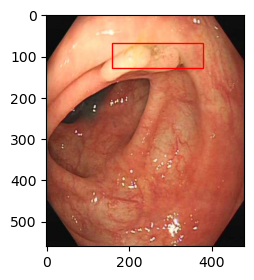

tensor([[  2., 114.,  35., 268.],
        [237., 200., 273., 249.]])


ValueError: not enough values to unpack (expected 4, got 2)

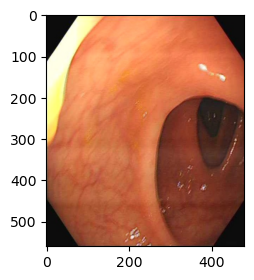

In [15]:
max_images_to_display = 5  # Set the maximum number of images to display
image_counter = 0    # Initialize a counter

# Set the desired figure size
fig_width, fig_height = 4, 3  # Adjust these values to your preference

# Test by iterating through the dataset
for image, target in train_dataloader:
    # Convert the PyTorch tensor to a NumPy array for visualization
    image = image.squeeze(0).permute(1, 2, 0).numpy()

    # Create a figure and axis
    fig, ax = plt.subplots(1, figsize=(fig_width, fig_height))
    ax.imshow(image)
    
    bounding_boxes = target['boxes']
    # Iterate through bounding boxes and draw them on the image
    if bounding_boxes.numel() > 0:
        for box in bounding_boxes:
            print(box)
            box = box.squeeze(0) # flatten the tensor to avoid unpacking error
            x1, y1, x2, y2 = box
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1, edgecolor='r', facecolor='none')
            ax.add_patch(rect)

    # Show the image with bounding boxes
    plt.show()
    
    # Increment the image counter
    image_counter += 1

    if image_counter >= max_images_to_display:
        break  # Exit the loop after displaying the desired number of images

### Select the device to train the model on 
(GPU by default if available)

In [16]:
import torch

# Enable MPS fallback
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

# Check if CUDA is available, which it will be on most Windows/Linux machines with NVIDIA GPUs
if torch.cuda.is_available():
    device = torch.device("cuda")
# elif torch.backends.mps.is_available():
#     device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cpu


### Define the data collate function for the DataLoader
(which combines multiple images into a batch)

### Define the model

In [30]:
from model_utils import *
# Define hyperparameters
param = {
    "BATCH_SIZE":  2,
    "LR" : 0.005,
    "WEIGHT_DECAY": 0.0005,
    "CONFIDENCE_THRESHOLD": 0.5
}


In [18]:
# Split the dataset into training and validation sets
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=param["BATCH_SIZE"], shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=param["BATCH_SIZE"], collate_fn=collate_fn)


In [19]:
# Modify the model for your specific dataset: Change the number of classes
num_classes = 2  # 1 class (polyp) + 1 background
model = get_model('FasterRCNN', num_classes)

# Define the optimizer and learning rate scheduler
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=param["LR"], momentum=0.9, weight_decay=param["WEIGHT_DECAY"])
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# Define the loss function
criterion = torch.nn.CrossEntropyLoss()

model = model.to(device)
print("Classes in the model's classifier:", model.roi_heads.box_predictor.cls_score.out_features)

Classes in the model's classifier: 2


### Test the training of the model to see if it works 

In [20]:
# For Training
images, targets = next(iter(train_loader))
images = [image.to(device) for image in images]
targets = [{k: v.to(device) for k, v in t.items()} for t in targets]  # Move targets to the device

output = model(images, targets)  # Returns losses and detections
print(output)

{'loss_classifier': tensor(0.5659, grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.0021, grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.0129, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0080, grad_fn=<DivBackward0>)}


{'boxes': tensor([[4.9609e+01, 4.8423e+00, 2.4734e+02, 2.0529e+02],
        [7.9171e+01, 4.8588e+01, 2.7954e+02, 1.7684e+02],
        [4.9047e-02, 9.0166e+01, 5.7424e+01, 5.2984e+02],
        [1.0543e+02, 1.3243e+02, 1.7810e+02, 3.4767e+02],
        [1.4984e+02, 1.3194e+02, 2.5655e+02, 3.7723e+02],
        [4.9880e+00, 4.0560e+01, 7.3809e+01, 1.2460e+02],
        [1.0954e+02, 2.6874e+01, 1.6158e+02, 1.1545e+02],
        [1.0087e+02, 1.5219e+02, 1.4107e+02, 3.1481e+02],
        [1.1264e+02, 1.6093e+02, 3.0485e+02, 3.5849e+02],
        [4.2039e+02, 1.3002e+02, 4.8000e+02, 5.0960e+02],
        [7.9874e+00, 0.0000e+00, 1.1342e+02, 2.0932e+02],
        [2.0495e+02, 3.2260e+00, 3.5025e+02, 1.5678e+02],
        [1.0775e+02, 7.1746e+01, 1.2046e+02, 9.6807e+01],
        [2.7874e+02, 4.7275e+01, 3.5117e+02, 1.3850e+02],
        [1.9166e+02, 3.6470e+02, 2.0294e+02, 3.8539e+02],
        [1.1464e+02, 7.3076e+01, 1.3680e+02, 1.2197e+02],
        [1.5557e+02, 8.2959e+01, 1.6749e+02, 1.1265e+02],
    

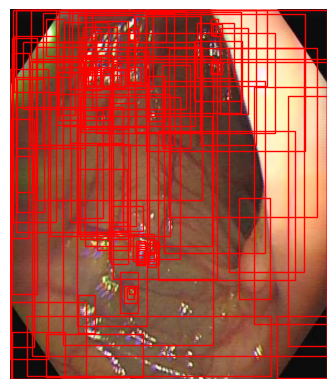

In [21]:
# For inference
model.eval()

# Get a batch of images from the DataLoader
images, targets = next(iter(train_loader))

# Select the first image from the batch for inference
# Assuming your DataLoader returns a batch of images and targets
image_to_infer = images[0].unsqueeze(0).to(device)  # Add batch dimension and move to the device

# Disable gradient computation since we're only doing inference
with torch.no_grad():
    # Perform inference
    predictions = model(image_to_infer)  # Returns predictions

    # Print out the predictions for the first image
    print(predictions[0])
    
# Process the first image and its prediction
image = image_to_infer[0].cpu().numpy()  # Move the tensor to cpu and convert to numpy
image = np.transpose(image, (1, 2, 0))  # Transpose from CxHxW to HxWxC for matplotlib

# Display the image
plt.imshow(image)
plt.axis('off')  # Turn off the axis

# Add the predicted bounding boxes
for box in predictions[0]['boxes']:
    xmin, ymin, xmax, ymax = box.cpu().numpy()
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=1, edgecolor='r', facecolor='none')
    plt.gca().add_patch(rect)

In [22]:
# # After training, you can plot the epoch losses
# plt.plot(epoch_losses, label='Training Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.title('Training Loss Over Epochs')
# plt.legend()
# plt.show()

## Data augmentation

### Data analysis

#### Bounding box analysis

In [57]:
# import importlib
# import data_utils
# importlib.reload(data_utils)
from clases.data_utils import *

In [23]:
# This can take a while to run!
# Assuming train_dataset is an instance of CustomDataset
all_bounding_boxes = get_all_bounding_boxes(train_dataset)
print("Number of bounding boxes:", len(all_bounding_boxes))

Number of bounding boxes: 17878


In [52]:
centers_bbox = get_bbox_centers(all_bounding_boxes)

Elbow method to determine ideal number of clusters

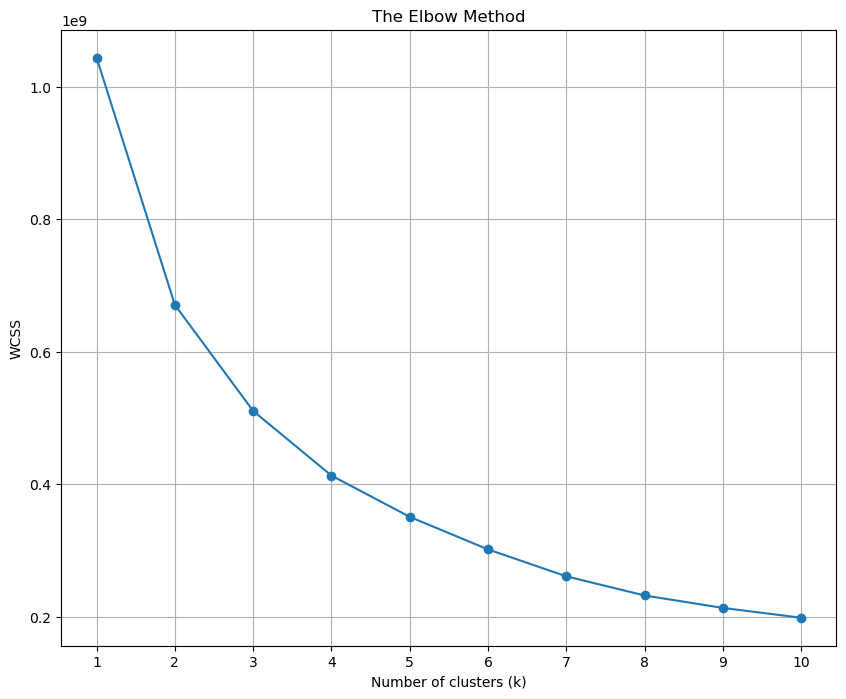

In [24]:
# Calculate WCSS for a range of number of clusters (within-cluster sum of squares)
wcss = calculate_wcss(all_bounding_boxes, max_k=10)
plot_elbow(wcss)

Silhouette score to determine ideal number of clusters (higher is better)

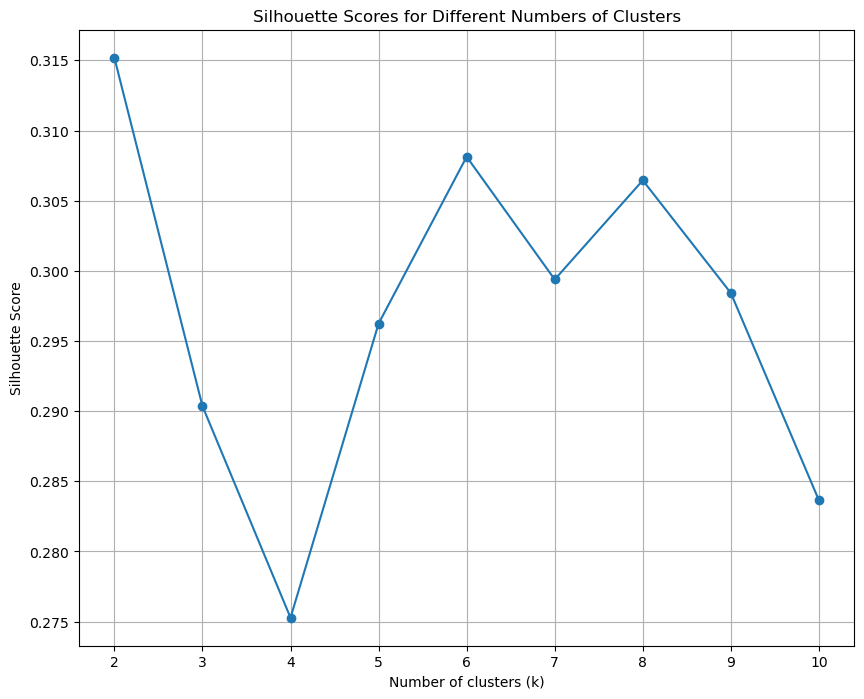

In [25]:
from sklearn.metrics import silhouette_score

# Calculate silhouette scores for a range of number of clusters
silhouette_scores = calculate_silhouette_scores(all_bounding_boxes, max_k=10)
plot_silhouette_scores(silhouette_scores)

In [54]:
# Use the function with your data
centers_8, labels_8 = cluster_bounding_boxes(all_bounding_boxes,8)
centers_3, labels_3 = cluster_bounding_boxes(all_bounding_boxes,3)
print("Cluster Centers:", centers_8)

/Users/pol/anaconda3/envs/TFG/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/pol/anaconda3/envs/TFG/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Cluster Centers: [[ 53.759476  86.04037  164.71484  233.8352  ]
 [234.38553  191.07695  334.54184  283.33136 ]
 [228.99597  333.4112   340.89392  416.1063  ]
 [402.30746  113.89177  485.85123  201.83823 ]
 [156.4025    77.34479  483.99588  439.4766  ]
 [376.43427  286.65622  474.60623  387.18857 ]
 [178.55295   54.237076 313.6652   133.36102 ]
 [ 85.3864   257.40744  188.59888  373.47815 ]]


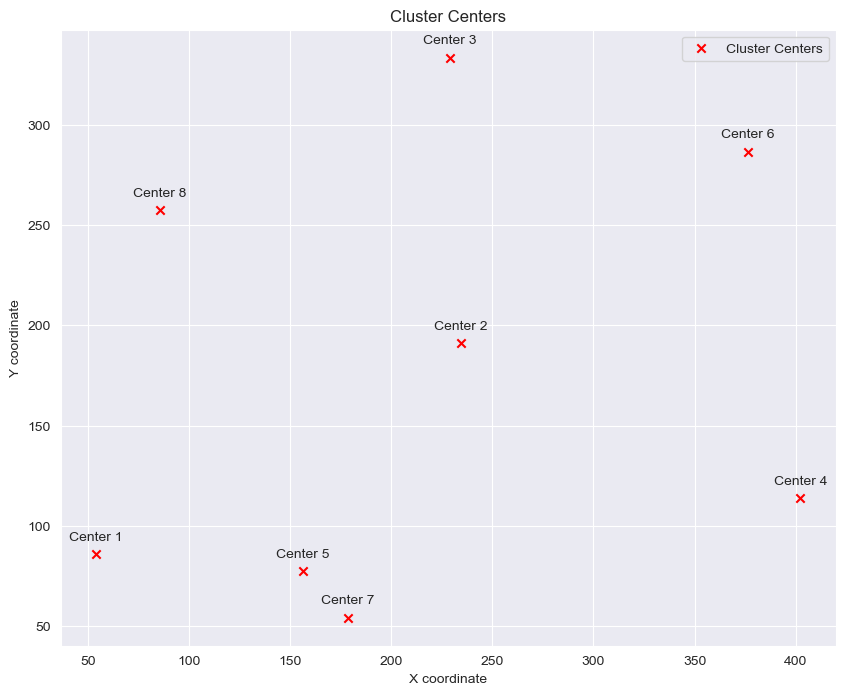

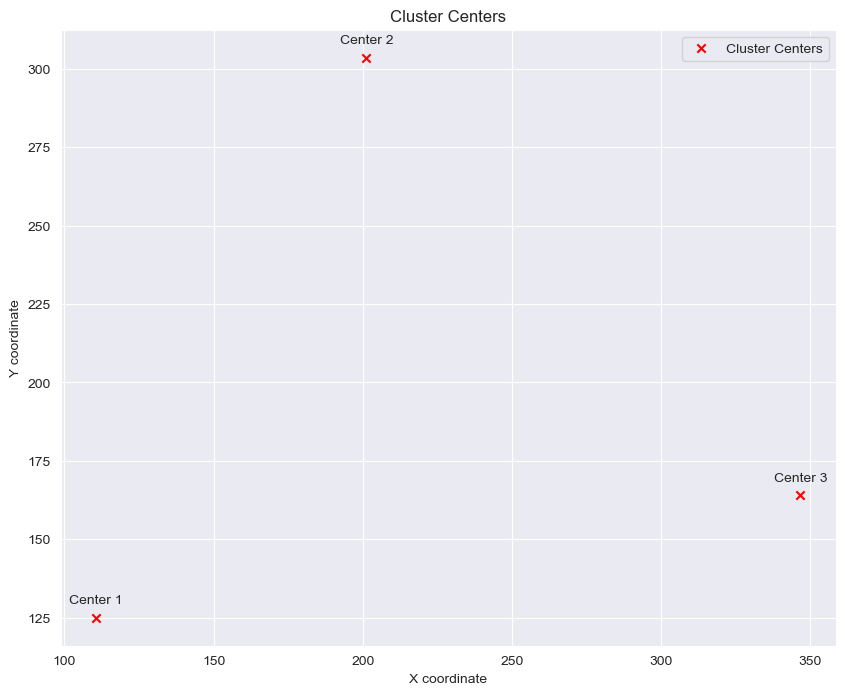

In [55]:
# Example usage
# Assume that `centers` contains the cluster centers calculated from your bounding boxes.
plot_cluster_centers(centers_8)
plot_cluster_centers(centers_3)


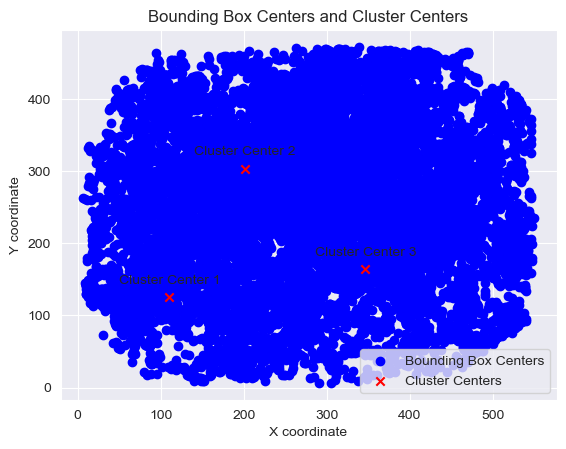

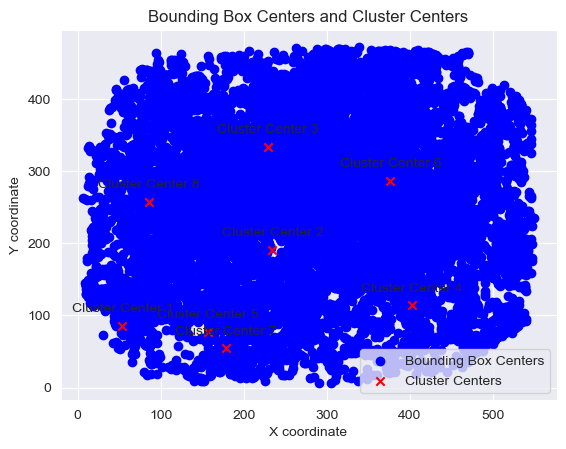

In [56]:
# Example usage
# Assume that `centers` contains the cluster centers calculated from your bounding boxes.
# Also, assume that `bounding_boxes` contains your bounding box data.
plot_cluster_centers_with_bbox_centers(centers_3, all_bounding_boxes)
plot_cluster_centers_with_bbox_centers(centers_8, all_bounding_boxes)


/Users/pol/anaconda3/envs/TFG/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/pol/anaconda3/envs/TFG/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/pol/anaconda3/envs/TFG/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/pol/anaconda3/envs/TFG/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version

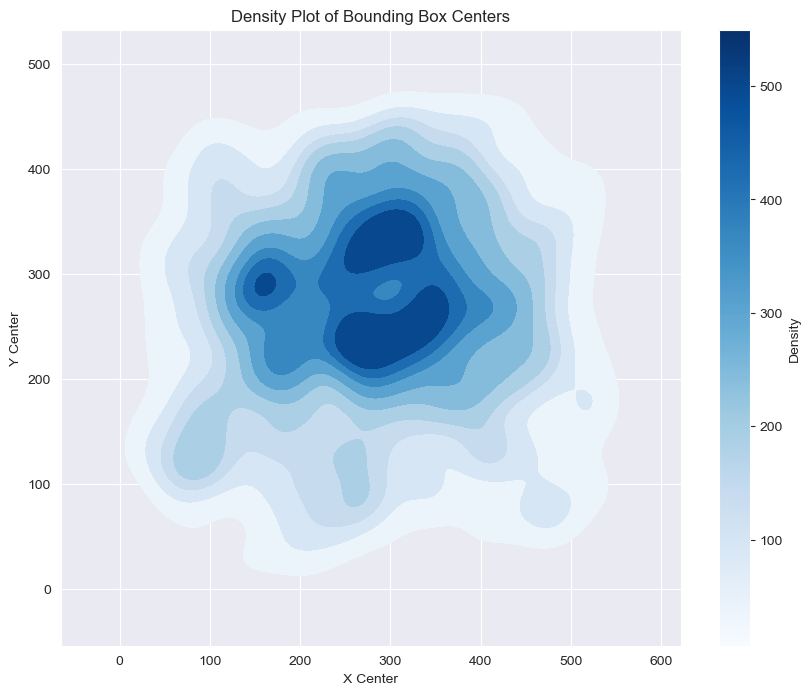

In [59]:
plot_density_of_bbox_centers(centers_bbox)
